In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/flight_data.csv')
data = df.copy()  # always work on a copy

print(data.shape)
data.head()

(300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [2]:
# 'flight' is just a flight code — no predictive value
data.drop(columns=['flight'], inplace=True)

print("Columns remaining:", data.columns.tolist())

Columns remaining: ['Unnamed: 0', 'airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [3]:
stops_mapping = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}

data['stops'] = data['stops'].map(stops_mapping)
print(data['stops'].value_counts())

stops
1    250863
0     36004
2     13286
Name: count, dtype: int64


In [4]:
data['class'] = data['class'].map({'Economy': 0, 'Business': 1})
print(data['class'].value_counts())

class
0    206666
1     93487
Name: count, dtype: int64


In [5]:
categorical_cols = [
    'airline', 'source_city', 'destination_city',
    'departure_time', 'arrival_time'
]

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", data.shape)
print("New columns:", data.columns.tolist())

Shape after encoding: (300153, 31)
New columns: ['Unnamed: 0', 'stops', 'class', 'duration', 'days_left', 'price', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night']


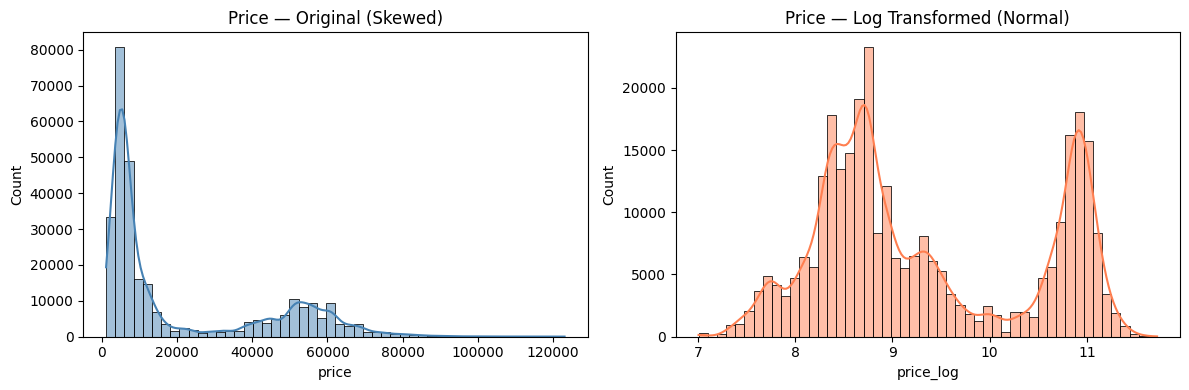

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data['price'], bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Price — Original (Skewed)')

# Apply log transform
data['price_log'] = np.log1p(data['price'])

sns.histplot(data['price_log'], bins=50, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Price — Log Transformed (Normal)')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['duration', 'days_left']
data[num_cols] = scaler.fit_transform(data[num_cols])

print(data[num_cols].describe())

           duration     days_left
count  3.001530e+05  3.001530e+05
mean   7.272249e-17  1.219617e-16
std    1.000002e+00  1.000002e+00
min   -1.583849e+00 -1.843875e+00
25%   -7.495873e-01 -8.115011e-01
50%   -1.350143e-01 -3.503368e-04
75%    5.490805e-01  8.845414e-01
max    5.229290e+00  1.695692e+00


In [8]:
# Drop original price (we'll predict log price)
X = data.drop(columns=['price', 'price_log'])
y = data['price_log']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (300153, 30)
Target shape: (300153,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (240122, 30)
Test size: (60031, 30)


In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("✅ Processed data saved!")

✅ Processed data saved!


In [13]:
# Check what columns were actually created
time_cols = [c for c in X_train.columns if 'departure_time' in c]
print(time_cols)


['departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night']
